In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from sklearn.linear_model import Ridge
import pandas as pd
%matplotlib inline

In [2]:
data_path = "/home/thappe/data/"

In [56]:
ls /home/thappe/data/ 

1940-2023_T2M_westEU_JJA.nc
MSLP_era5_NHmidlats_0.25degr_1940_2023_JJA.nc
NASA_GMST.csv
STREAM500_era5_ExtendedWestEU_0.25degr_1940_2022_JJA.nc


##  ERA5 Data

In [57]:
T2M_file = "1940-2023_T2M_westEU_JJA.nc"
STREAM500_file = "STREAM500_era5_ExtendedWestEU_0.25degr_1940_2022_JJA.nc"

In [58]:
t2m = xr.open_dataset(f"{data_path}{T2M_file}")
stream500 = xr.open_dataset(f"{data_path}{STREAM500_file}")

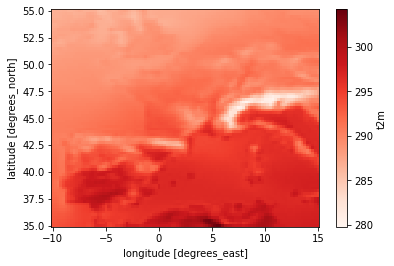

In [6]:
t2m_climatology = t2m['t2m'].mean(dim="time")
t2m_climatology.plot(cmap="Reds")


In [ ]:
stream500_clim = stream500['stream'].mean(dim="time")
stream500_clim.plot(cmap="PiYG")


## NASA yearly GMST

In [7]:
yearly_GMST = pd.read_csv(f"{data_path}NASA_GMST.csv", delimiter=";", skiprows=1, index_col=0)

<AxesSubplot:xlabel='Year'>

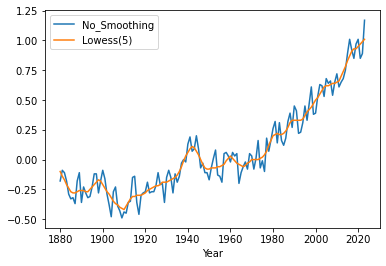

In [8]:
yearly_GMST.plot()

### convert to xarray to have same shape as t2m

In [55]:
## this is from 1940-2023, JJA (92 days)
LOWESS5y_yearly_GMST = yearly_GMST["Lowess(5)"][-84:].to_numpy() ## select 1940-2023

GMST_reshaped = np.empty(7728,) #empty array with shape of number of days (e.g 92 per summer, per year)

for i, GMST in enumerate(LOWESS5y_yearly_GMST): ## loop over the GMST data to fill the array
    year_array = np.array(92 * [GMST], dtype=float)
    GMST_reshaped[i*92:(i+1)*92] = year_array[:]
    
#create xarray 
GMST_xr = xr.DataArray(
    data=GMST_reshaped,
    dims=["time"],
    coords=dict(
        time=t2m.time.dt.year,
    ),
    attrs=dict(
        description="Global Mean Surface Temperature anomalie from NASA, 5 year LOWESS",
        units="degC",
    ),
)

## ridge

https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.Ridge.html

In [ ]:
# standardize data 
#for LAND grid point in t2m data == Y
#select the corresponding stream500 input fields (lon,lat bounds)  == X1
# get the GMST data for all years, shape this to (days,) == X2 
# train the ridge model 

## then you can get the coef_ for the GMST and take this out 

In [53]:
GMST_xr

<xarray.DataArray (time: 7728)>
array([0.06, 0.06, 0.06, ..., 1.01, 1.01, 1.01])
Coordinates:
  * time     (time) int64 1940 1940 1940 1940 1940 ... 2023 2023 2023 2023 2023
Attributes:
    description:  Global Mean Surface Temperature anomalie from NASA, 5 year ...
    units:        degC

In [ ]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X, y)